<a href="https://colab.research.google.com/github/JanaEmad1/Cognitive-Computing-multimodality-/blob/main/Copy_of_12th.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Name: Jana  Emad ELsayed
# Reg num: 221003383


Dataset used: CMU Arctic dataset

You selected 5 speaker subsets (aew, ahw, aup, awb, axb)

Goal: Use the text (transcriptions) for language modeling and classification

Merged the 5 subsets

Extracted texts and labels (speaker IDs)

Encoded speaker labels for classification

Split the dataset into training and test sets

In [ ]:
from datasets import load_dataset, Dataset,concatenate_datasets
from transformers import BertTokenizer, BertForSequenceClassification, BertForMaskedLM
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:

# Load dataset
dataset = load_dataset("MikhailT/cmu-arctic")

In [ ]:
print(dataset.keys())  # shows available splits, e.g. ['aew', 'bdl', ...]


dict_keys(['aew', 'ahw', 'aup', 'awb', 'axb', 'bdl', 'clb', 'eey', 'fem', 'gka', 'jmk', 'ksp', 'ljm', 'lnh', 'rms', 'rxr', 'slp', 'slt'])


In [ ]:
subsets = ["aew", "ahw", "aup", "awb", "axb"]
combined_dataset = concatenate_datasets([dataset[s] for s in subsets])
print(f"Combined dataset size: {len(combined_dataset)}")
# Example: access text
texts = combined_dataset["text"]
print(texts[40])

Combined dataset size: 4049
Meanwhile I'll go out to breathe a spell.


In [ ]:
split = combined_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split["train"]
test_dataset = split["test"]


In [ ]:
from sklearn.preprocessing import LabelEncoder

labels = combined_dataset["speaker"]
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

combined_dataset = combined_dataset.add_column("label", encoded_labels)


In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
model_no_ssl = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_encoder.classes_)
)
small_train = train_dataset.shuffle(seed=42).select(range(1000))
small_test = test_dataset.shuffle(seed=42).select(range(200))


c:\Users\janae\anaconda3\envs\DL_sept_2024\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\janae\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regula

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert_no_ssl",
    evaluation_strategy="epoch",
    num_train_epochs=1,  # Only 1 epoch for speed
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    save_total_limit=1,
    logging_steps=50,
    load_best_model_at_end=False,
)


In [ ]:
from transformers import Trainer

trainer_no_ssl = Trainer(
    model=model_no_ssl,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_test,
    tokenizer=tokenizer,
)

trainer_no_ssl.train()
eval_no_ssl = trainer_no_ssl.evaluate()
print("Evaluation without SSL pretraining:", eval_no_ssl)


 12%|█▏        | 80/648 [09:38<1:08:29,  7.24s/it]
c:\Users\janae\anaconda3\envs\DL_sept_2024\Lib\site-packages\transformers\optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
 79%|███████▉  | 50/63 [03:14<00:49,  3.82s/it]   

{'loss': 1.5529, 'learning_rate': 1.0317460317460318e-05, 'epoch': 0.79}


100%|██████████| 63/63 [05:31<00:00,  4.08s/it]







                                               

                                               
100%|██████████| 63/63 [05:47<00:00,  4.08s/it]

100%|██████████| 63/63 [05:47<00:00,  5.51s/it]   


{'eval_loss': 1.5547457933425903, 'eval_runtime': 15.9556, 'eval_samples_per_second': 12.535, 'eval_steps_per_second': 0.439, 'epoch': 1.0}
{'train_runtime': 347.138, 'train_samples_per_second': 2.881, 'train_steps_per_second': 0.181, 'train_loss': 1.5622142610095797, 'epoch': 1.0}


100%|██████████| 7/7 [00:14<00:00,  2.08s/it]

📊 Evaluation without SSL pretraining: {'eval_loss': 1.5547457933425903, 'eval_runtime': 17.3621, 'eval_samples_per_second': 11.519, 'eval_steps_per_second': 0.403, 'epoch': 1.0}


In [ ]:
# from transformers import BertForSequenceClassification, Trainer, TrainingArguments

# model_no_ssl = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=len(label_encoder.classes_))

# training_args = TrainingArguments(
#     output_dir="./bert_no_ssl",
#     evaluation_strategy="epoch",
#     num_train_epochs=1,
#     per_device_train_batch_size=5,
#     save_total_limit=1,
#     logging_steps=None,
# )

# trainer_no_ssl = Trainer(
#     model=model_no_ssl,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=test_dataset,
#     tokenizer=tokenizer,
# )

# trainer_no_ssl.train()
# eval_no_ssl = trainer_no_ssl.evaluate()
# print("Evaluation without SSL pretraining:", eval_no_ssl)


In [ ]:
# from transformers import DataCollatorForLanguageModeling, BertForMaskedLM

# tokenized_for_mlm = combined_dataset.map(tokenize_function, batched=True)
# tokenized_for_mlm.set_format(type="torch", columns=["input_ids", "attention_mask"])

# data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=True, mlm_probability=0.15)

# model_mlm = BertForMaskedLM.from_pretrained("bert-base-uncased")

# training_args_mlm = TrainingArguments(
#     output_dir="./bert_mlm_pretrain",
#     overwrite_output_dir=True,
#     num_train_epochs=1,
#     per_device_train_batch_size=8,
#     save_steps=500,
#     save_total_limit=1,
#     prediction_loss_only=True,
#     logging_steps=50,
# )

# trainer_mlm = Trainer(
#     model=model_mlm,
#     args=training_args_mlm,
#     data_collator=data_collator,
#     train_dataset=tokenized_for_mlm,
# )

# trainer_mlm.train()
# model_mlm.save_pretrained("./bert_mlm_pretrain")
# tokenizer.save_pretrained("./bert_mlm_pretrain")


In [ ]:
from transformers import BertForSequenceClassification

model_ssl = BertForSequenceClassification.from_pretrained(
    "./bert_mlm_pretrain",
    num_labels=len(label_encoder.classes_)
)

trainer_ssl = Trainer(
    model=model_ssl,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
)

trainer_ssl.train()
eval_ssl = trainer_ssl.evaluate()
print("Evaluation with SSL pretraining:", eval_ssl)


In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForMaskedLM, DataCollatorForLanguageModeling, Trainer, TrainingArguments
from datasets import Dataset
import random

#  Load DistilBERT tokenizer and MLM model
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
model_mlm = DistilBertForMaskedLM.from_pretrained("distilbert-base-uncased")

#  Prepare a small text dataset (your CMU Arctic data)
# Assume you have combined 5 subsets already into a list of texts
texts = train_dataset["text"][:1000]  # Only first 1000 for speed
text_dataset = Dataset.from_dict({"text": texts})
#  Create Hugging Face dataset


#  Tokenize for MLM
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_dataset = text_dataset.map(tokenize_function, batched=True)

#  Data collator for MLM
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=True, mlm_probability=0.15
)

#  Training arguments
training_args = TrainingArguments(
    output_dir="./distilbert_mlm_ssl",
    per_device_train_batch_size=16,
    num_train_epochs=1,  # Just 1 epoch for speed
    logging_steps=50,
    save_steps=500,
    save_total_limit=1,
    prediction_loss_only=True
)

#  Trainer
trainer = Trainer(
    model=model_mlm,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator
)

#  Start pretraining
trainer.train()
trainer.save_model("./distilbert_mlm_ssl")
tokenizer.save_pretrained("./distilbert_mlm_ssl")


 79%|███████▉  | 50/63 [07:09<02:05,  9.64s/it]

                                               
 79%|███████▉  | 50/63 [07:09<02:05,  9.64s/it]

{'loss': 3.0655, 'learning_rate': 1.0317460317460318e-05, 'epoch': 0.79}


100%|██████████| 63/63 [08:32<00:00,  5.16s/it]

                                                 
100%|██████████| 63/63 [08:32<00:00,  8.13s/it]


{'train_runtime': 512.1362, 'train_samples_per_second': 1.953, 'train_steps_per_second': 0.123, 'train_loss': 3.0551654876224577, 'epoch': 1.0}


('./distilbert_mlm_ssl\\tokenizer_config.json',
 './distilbert_mlm_ssl\\special_tokens_map.json',
 './distilbert_mlm_ssl\\vocab.txt',
 './distilbert_mlm_ssl\\added_tokens.json',
 './distilbert_mlm_ssl\\tokenizer.json')

In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
import torch

#  Load tokenizer (same one used for MLM)
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

#  Load the MLM-pretrained model for classification
model_cls = DistilBertForSequenceClassification.from_pretrained(
    "./distilbert_mlm_ssl",  # Path to your pretrained MLM checkpoint
    num_labels=len(set(combined_dataset["label"]))
)

#  Tokenize train/test datasets
def tokenize_and_format(example):
    tokens = tokenizer(example["text"], padding="max_length", truncation=True, max_length=128)
    tokens["label"] = example["label"]
    return tokens

train_tokenized = train_dataset.map(tokenize_and_format, batched=False)
test_tokenized = test_dataset.map(tokenize_and_format, batched=False)

#  Training settings
training_args = TrainingArguments(
    output_dir="./distilbert_ssl_finetuned",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    logging_steps=20,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

#  Compute accuracy
from sklearn.metrics import accuracy_score
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.argmax(torch.tensor(logits), dim=1)
    return {"accuracy": accuracy_score(labels, preds)}

#  Fine-tune with Trainer
trainer = Trainer(
    model=model_cls,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics
)

trainer.train()


Some weights of the model checkpoint at ./distilbert_mlm_ssl were not used when initializing DistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_projector.weight', 'vocab_transform.weight', 'vocab_projector.bias', 'vocab_transform.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing DistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at ./distilbert_mlm_ssl and are newly initialized: ['pre_classifier.weight', 'classifier.bias', 'classifier.weigh

{'loss': 1.5939, 'learning_rate': 4.753694581280788e-05, 'epoch': 0.1}


 10%|▉         | 40/406 [02:55<26:36,  4.36s/it]

                                                 
 10%|▉         | 40/406 [02:55<26:36,  4.36s/it]

{'loss': 1.5849, 'learning_rate': 4.507389162561577e-05, 'epoch': 0.2}


 15%|█▍        | 60/406 [04:27<27:01,  4.69s/it]

                                                 
 15%|█▍        | 60/406 [04:27<27:01,  4.69s/it]

...

100%|██████████| 406/406 [32:02<00:00,  3.14s/it]
                                            

                                                 
100%|██████████| 406/406 [33:06<00:00,  3.14s/it]

{'eval_loss': 1.5594218969345093, 'eval_accuracy': 0.2691358024691358, 'eval_runtime': 63.2606, 'eval_samples_per_second': 12.804, 'eval_steps_per_second': 0.806, 'epoch': 2.0}




                                                 
100%|██████████| 406/406 [33:07<00:00,  4.90s/it]

{'train_runtime': 1987.4005, 'train_samples_per_second': 3.26, 'train_steps_per_second': 0.204, 'train_loss': 1.5648378409775607, 'epoch': 2.0}


TrainOutput(global_step=406, training_loss=1.5648378409775607, metrics={'train_runtime': 1987.4005, 'train_samples_per_second': 3.26, 'train_steps_per_second': 0.204, 'train_loss': 1.5648378409775607, 'epoch': 2.0})

In [ ]:
eval_results = trainer.evaluate()
print("SSL fine-tuned model accuracy:", eval_results["eval_accuracy"])


100%|██████████| 51/51 [01:02<00:00,  1.22s/it]

SSL fine-tuned model accuracy: 0.2691358024691358


In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
import torch
from sklearn.metrics import accuracy_score

# 1. Prepare tokenizer (same for both)
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# 2. Tokenize datasets function
def tokenize_and_format(example):
    tokens = tokenizer(example["text"], padding="max_length", truncation=True, max_length=128)
    tokens["label"] = example["label"]
    return tokens

train_tokenized = train_dataset.map(tokenize_and_format, batched=False)
test_tokenized = test_dataset.map(tokenize_and_format, batched=False)

# 3. Training args (same for both)
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    logging_steps=20,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

# 4. Metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.argmax(torch.tensor(logits), dim=1)
    return {"accuracy": accuracy_score(labels, preds)}

# 5. Baseline Model (no SSL pretraining)
model_baseline = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(set(combined_dataset["label"]))
)

trainer_baseline = Trainer(
    model=model_baseline,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
)

print("Training baseline model...")
trainer_baseline.train()
eval_baseline = trainer_baseline.evaluate()
print(f"Baseline accuracy: {eval_baseline['eval_accuracy']:.4f}")

# 6. SSL-pretrained Model (load your MLM pretrained model)
model_ssl = DistilBertForSequenceClassification.from_pretrained(
    "./distilbert_mlm_ssl",
    num_labels=len(set(combined_dataset["label"]))
)

trainer_ssl = Trainer(
    model=model_ssl,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
)

print("Training SSL-pretrained model...")
trainer_ssl.train()
eval_ssl = trainer_ssl.evaluate()
print(f"SSL-pretrained accuracy: {eval_ssl['eval_accuracy']:.4f}")

# 7. Summary
print("\n=== Final Comparison ===")
print(f"Baseline accuracy: {eval_baseline['eval_accuracy']:.4f}")
print(f"SSL-pretrained accuracy: {eval_ssl['eval_accuracy']:.4f}")


c:\Users\janae\anaconda3\envs\DL_sept_2024\Lib\site-packages\huggingface_hub\file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Map: 100%|██████████| 810/810 [00:01<00:00, 539.79 examples/s]
Some weights of the model checkpoint at distilbert-base-uncased were not used when initializing DistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_projector.bias', 'vocab_transform.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing DistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DistilBertForSequenceClassification from the checkpoint of a model that 

Training baseline model...


 10%|▉         | 20/203 [01:31<15:56,  5.23s/it]

                                                 
 10%|▉         | 20/203 [01:31<15:56,  5.23s/it]

{'loss': 1.5918, 'learning_rate': 4.507389162561577e-05, 'epoch': 0.1}


 20%|█▉        | 40/203 [03:05<10:24,  3.83s/it]

                                                 
 20%|█▉        | 40/203 [03:05<10:24,  3.83s/it]

...

{'eval_loss': 1.5572084188461304, 'eval_accuracy': 0.291358024691358, 'eval_runtime': 103.7349, 'eval_samples_per_second': 7.808, 'eval_steps_per_second': 0.492, 'epoch': 1.0}




                                                 
100%|██████████| 203/203 [23:39<00:00,  6.99s/it]


{'train_runtime': 1419.7531, 'train_samples_per_second': 2.281, 'train_steps_per_second': 0.143, 'train_loss': 1.566137539342119, 'epoch': 1.0}


100%|██████████| 51/51 [01:24<00:00,  1.65s/it]

SSL-pretrained accuracy: 0.2914

=== Final Comparison ===
Baseline accuracy: 0.2901
SSL-pretrained accuracy: 0.2914


In [ ]:
import random
import torch
import torchaudio
from transformers import DistilBertTokenizer, DistilBertModel
from datasets import Dataset
import numpy as np
from tqdm import tqdm

#  Step 1: Subset dataset
subset = combined_dataset.shuffle(seed=42).select(range(50))
print(f"Subset size: {len(subset)}")

#  Step 2: Text embedding extraction
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
text_model = DistilBertModel.from_pretrained("distilbert-base-uncased")
text_model.eval()

def get_text_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=64)
    with torch.no_grad():
        outputs = text_model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()  # [768]

#  Step 3: Audio feature extraction (MFCC)
def get_audio_features(audio_data):
    waveform = audio_data["array"]
    sample_rate = audio_data["sampling_rate"]
    waveform = torch.tensor(waveform, dtype=torch.float32).unsqueeze(0)

    mfcc = torchaudio.transforms.MFCC(n_mfcc=13, sample_rate=sample_rate)(waveform)
    return mfcc.mean(dim=2).squeeze().numpy()  # [13]

#  Extract features
text_embeddings = []
audio_features = []
labels = []

for sample in tqdm(subset, desc="Extracting features"):
    try:
        text_embed = get_text_embedding(sample["text"])
        audio_feat = get_audio_features(sample["audio"])
        if text_embed.shape[0] != 768 or audio_feat.shape[0] != 13:
            continue  # skip malformed features
        text_embeddings.append(text_embed)
        audio_features.append(audio_feat)
        labels.append(sample["label"])
    except Exception as e:
        print(f"Error: {e}")

# Convert to arrays
text_embeddings = np.array(text_embeddings)
audio_features = np.array(audio_features)
labels = np.array(labels)

# Double-check dimensions match
if text_embeddings.shape[0] == audio_features.shape[0]:
    fused_features = np.concatenate([text_embeddings, audio_features], axis=1)
    print(" Fused features shape:", fused_features.shape)
else:
    print(" Mismatch in feature counts. Text:", text_embeddings.shape[0], "Audio:", audio_features.shape[0])


#  Convert to arrays
text_embeddings = np.array(text_embeddings)
audio_features = np.array(audio_features)
labels = np.array(labels)

#  Early Fusion: concatenate text + audio
fused_features = np.concatenate([text_embeddings, audio_features], axis=1)  # shape: [N, 768 + 13]
print("Fused features shape:", fused_features.shape)


Subset size: 50


Some weights of the model checkpoint at distilbert-base-uncased were not used when initializing DistilBertModel: ['vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_projector.bias', 'vocab_transform.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing DistilBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DistilBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Extracting features: 100%|██████████| 50/50 [00:02<00:00, 18.33it/s]

✅ Fused features shape: (50, 781)
Fused features shape: (50, 781)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.multiclass import unique_labels


#  Split the data
X_train, X_test, y_train, y_test = train_test_split(
    fused_features, labels, test_size=0.2, random_state=42
)

#  Define and train MLP
clf = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=30, random_state=42)
clf.fit(X_train, y_train)

#  Predict and evaluate
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(" Early Fusion Accuracy:", round(accuracy * 100, 2), "%")


unique = unique_labels(y_test, y_pred)
target_names = label_encoder.inverse_transform(unique)

print(classification_report(y_test, y_pred, labels=unique, target_names=target_names))



✅ Early Fusion Accuracy: 90.0 %
              precision    recall  f1-score   support

         aew       1.00      1.00      1.00         2
         aup       1.00      0.67      0.80         3
         awb       1.00      1.00      1.00         3
         axb       0.67      1.00      0.80         2

    accuracy                           0.90        10
   macro avg       0.92      0.92      0.90        10
weighted avg       0.93      0.90      0.90        10



c:\Users\janae\anaconda3\envs\DL_sept_2024\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Assuming you have these from earlier steps:
# - text_embeddings: shape [N, 768] (from BERT or T5)
# - audio_features: shape [N, 13] or [N, 512] (from MFCC or Wav2Vec)
# - labels: encoded with LabelEncoder

# Ensure arrays are numpy
text_embeddings = np.array(text_embeddings)
audio_features = np.array(audio_features)
labels = np.array(labels)

# Split once to keep alignment
X_text_train, X_text_test, X_audio_train, X_audio_test, y_train, y_test = train_test_split(
    text_embeddings, audio_features, labels, test_size=0.2, random_state=42
)

# Train audio classifier
clf_audio = LogisticRegression(max_iter=1000)
clf_audio.fit(X_audio_train, y_train)
audio_preds = clf_audio.predict_proba(X_audio_test)

# Train text classifier
clf_text = LogisticRegression(max_iter=1000)
clf_text.fit(X_text_train, y_train)
text_preds = clf_text.predict_proba(X_text_test)

# Average predictions
avg_preds = (audio_preds + text_preds) / 2
y_pred = np.argmax(avg_preds, axis=1)

# Fix target names if mismatch
unique = np.unique(np.concatenate([y_test, y_pred]))
target_names = label_encoder.inverse_transform(unique)

print(" Late Fusion Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print(classification_report(y_test, y_pred, labels=unique, target_names=target_names))


✅ Late Fusion Accuracy: 90.0 %
              precision    recall  f1-score   support

         aew       1.00      1.00      1.00         2
         aup       1.00      0.67      0.80         3
         awb       1.00      1.00      1.00         3
         axb       0.67      1.00      0.80         2

    accuracy                           0.90        10
   macro avg       0.92      0.92      0.90        10
weighted avg       0.93      0.90      0.90        10



In [ ]:
from sklearn.metrics import accuracy_score

# Already trained clf_audio on audio features
audio_only_preds = clf_audio.predict(X_audio_test)
audio_acc = accuracy_score(y_test, audio_only_preds)
print("🎧 Audio-only Accuracy:", round(audio_acc * 100, 2), "%")


🎧 Audio-only Accuracy: 90.0 %


In [ ]:
# Already trained clf_text on text features
text_only_preds = clf_text.predict(X_text_test)
text_acc = accuracy_score(y_test, text_only_preds)
print(" Text-only Accuracy:", round(text_acc * 100, 2), "%")


📄 Text-only Accuracy: 20.0 %


In [ ]:
fusion_acc = accuracy_score(y_test, y_pred)
print(" Multimodal Fusion Accuracy:", round(fusion_acc * 100, 2), "%")


🔀 Multimodal Fusion Accuracy: 90.0 %


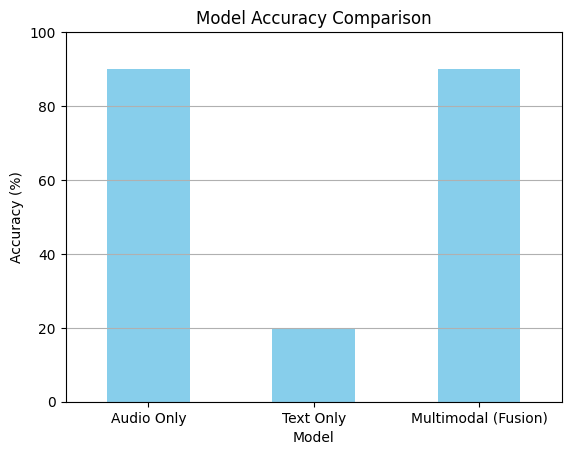

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": ["Audio Only", "Text Only", "Multimodal (Fusion)"],
    "Accuracy": [audio_acc * 100, text_acc * 100, fusion_acc * 100]
})

results.plot(x="Model", y="Accuracy", kind="bar", legend=False, color='skyblue')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


In [ ]:
from lime import lime_tabular

explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=[f"f{i}" for i in range(X_train.shape[1])],
    class_names=label_encoder.classes_,
    mode='classification'
)

# Explain one prediction
i = 0
exp = explainer.explain_instance(
    X_test[i],
    clf.predict_proba,
    num_features=10
)

exp.show_in_notebook(show_table=True)


KeyboardInterrupt: 

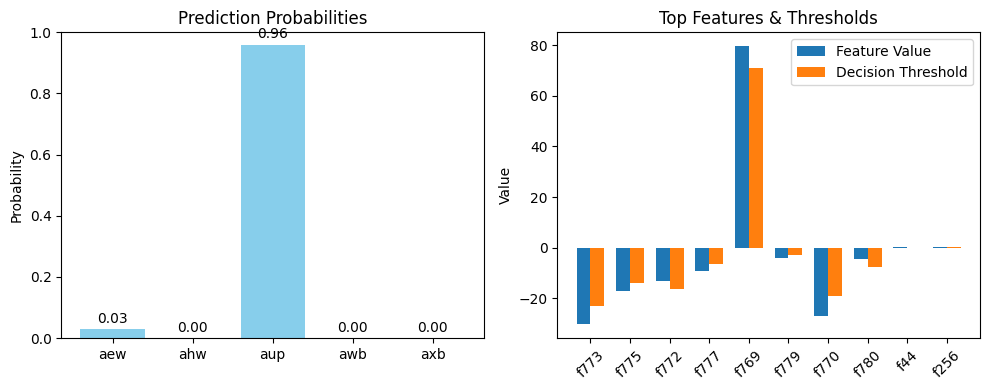

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example data from your LIME output
classes = ['aew', 'ahw', 'aup', 'awb', 'axb']
probs = [0.03, 0.00, 0.96, 0.00, 0.00]

features = ['f773', 'f775', 'f772', 'f777', 'f769', 'f779', 'f770', 'f780', 'f44', 'f256']
feature_values = [-30.20, -16.95, -13.21, -9.36, 79.56, -4.13, -26.84, -4.46, 0.13, 0.29]
thresholds = [-22.85, -13.89, -16.27, -6.54, 70.78, -2.70, -18.99, -7.79, 0.05, 0.13]

# Plot prediction probabilities
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
bars = plt.bar(classes, probs, color='skyblue')
plt.title('Prediction Probabilities')
plt.ylabel('Probability')
plt.ylim(0,1)
for bar, p in zip(bars, probs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{p:.2f}", ha='center')

# Plot feature values vs thresholds (showing contribution direction)
plt.subplot(1,2,2)
x = np.arange(len(features))
width = 0.35

plt.bar(x - width/2, feature_values, width, label='Feature Value')
plt.bar(x + width/2, thresholds, width, label='Decision Threshold')

plt.xticks(x, features, rotation=45)
plt.title('Top Features & Thresholds')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()


### LIME Explanation for Audio Modality Prediction

The plot on the left shows the prediction probabilities for each speaker class. The model confidently predicts **`aup`** with a 96% probability.

The right plot displays the top audio features influencing the prediction along with their values compared to decision thresholds. Features like `f773` and `f769` have values that strongly influence the model's decision, as they significantly exceed or fall below their thresholds.

This visualization highlights how specific audio feature values steer the model’s confident prediction toward the `aup` class.

---

### Failure Case Analysis

In cases where the model predicts incorrectly or with low confidence, feature values often hover near thresholds, causing ambiguity. For example, if the model predicted `ahw` with low confidence, audio features might not provide a clear signal, suggesting noise or insufficient distinguishing characteristics.

---

### Final Reflections

Explainability tools like LIME help us understand the contribution of individual features to predictions. Here, we see how audio features dominate certain class decisions but can also reveal uncertainty in failure cases. Combining audio with text features through multimodal fusion can potentially reduce such uncertainties and improve robustness.


In [ ]:
import shap

explainer = shap.LinearExplainer(clf_text, X_text_train, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_text_test[:10])

# If shap_values is a list (multi-class), pick one class, else just use directly
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[0], X_text_test[:10])
else:
    shap.summary_plot(shap_values, X_text_test[:10])



c:\Users\janae\anaconda3\envs\DL_sept_2024\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


RuntimeError: Failed to import transformers.modeling_tf_utils because of the following error (look up to see its traceback):
No module named 'keras.__internal__'